# Tarea 2 - Deep Learning

## Modelo base

### Imports

In [228]:
import torch
import torch.nn as nn
from torchmetrics.classification import BinaryCalibrationError
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
from sklearn.preprocessing import RobustScaler
from torch.utils.data import Dataset, DataLoader
import pickle
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_auc_score, RocCurveDisplay



### Cargando dispositivo (GPU o CPU)

In [229]:
if torch.cuda.is_available():
    print(f"CUDA disponible, usando {torch.cuda.get_device_name()}")
    device = torch.device("cuda")
else:
    print("CUDA no disponible, usando CPU")
    device = torch.device("cpu")

CUDA disponible, usando NVIDIA GeForce RTX 3050 Laptop GPU


### Cargando dataset

In [230]:
data = pd.read_pickle("data_train_2.pkl")

temp = torch.tensor(data['temp_images']).reshape(-1,21,21)
snr = torch.tensor(data['SNR_images']).reshape(-1,21,21)
diff = torch.tensor(data['diff_images']).reshape(-1,21,21)
sci = torch.tensor(data['sci_images']).reshape(-1,21,21)

X = torch.stack([temp, snr, diff, sci], dim=1)
y = torch.tensor(data["labels"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=data["labels"])
X_test, X_val, y_test, y_val = train_test_split(X_test, y_test, test_size=0.5, random_state=42, stratify=y_test)

### Escalado con RobustScaler y restricción de valores para outliers

In [231]:
n = X_train.shape[0]

scalers = []
for c in range(4):
    scaler = RobustScaler()
    ch_train = X_train[:, c].reshape(-1, 1).numpy()
    scaler.fit(ch_train)
    scalers.append(scaler)
    
    X_train[:, c] = torch.tensor(
        scaler.transform(ch_train).reshape(n, 21, 21), dtype=torch.float32)
    X_val[:, c] = torch.tensor(
        scaler.transform(X_val[:, c].reshape(-1, 1).numpy()).reshape(-1, 21, 21), dtype=torch.float32)
    X_test[:, c] = torch.tensor(
        scaler.transform(X_test[:, c].reshape(-1, 1).numpy()).reshape(-1, 21, 21), dtype=torch.float32)


with open('scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)

Observar valores extremos

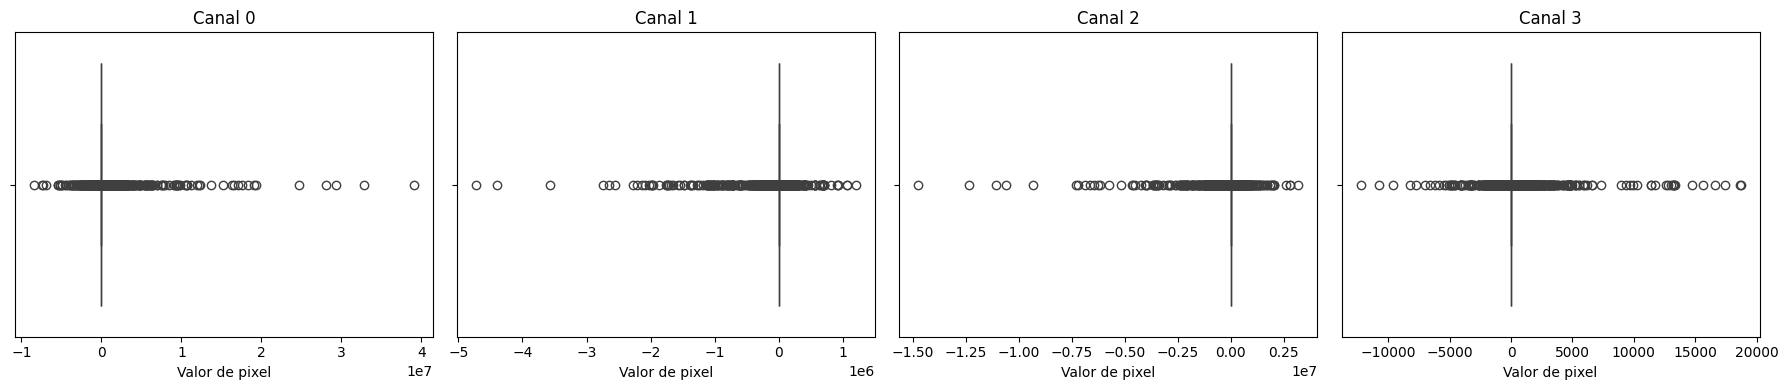

In [232]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for channel in range(4):
    vals = X_train[:, channel].reshape(-1).cpu().numpy()
    sns.boxplot(x=vals, ax=axes[channel])
    axes[channel].set_title(f'Canal {channel}')
    axes[channel].set_xlabel('Valor de pixel')

plt.tight_layout()
plt.show()

Reescalando para mantener 90% de la información


In [233]:

for c in range(4):
    p5  = X_train[:, c].quantile(0.05)
    p95 = X_train[:, c].quantile(0.95)
    
    for split in [X_train, X_val, X_test]:
        split[:, c] = split[:, c].clamp(p5, p95)
        split[:, c] = (split[:, c] - p5) / (p95 - p5) * 2 - 1

Mantenemos información a costa de tener algunos outliers

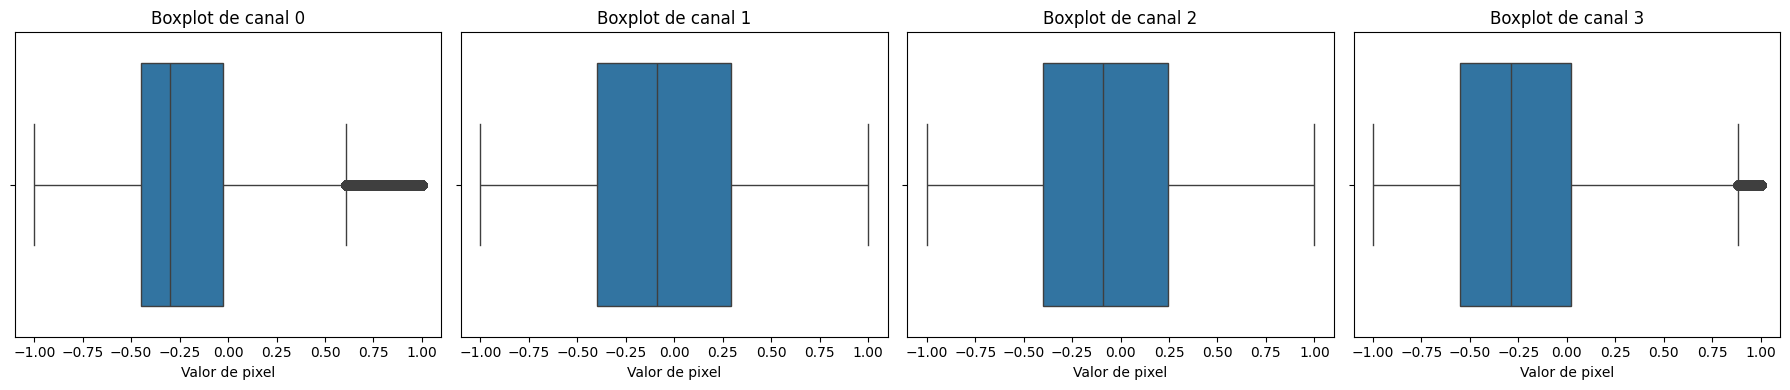

In [234]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for channel in range(4):
    vals = X_train[:, channel].reshape(-1).cpu().numpy()
    sns.boxplot(x=vals, ax=axes[channel])
    axes[channel].set_title(f'Boxplot de canal {channel}')
    axes[channel].set_xlabel('Valor de pixel')

plt.tight_layout()
plt.show()

In [235]:
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
X_val, y_val = X_val.to(device), y_val.to(device)


### Definicion de los dataloaders y tamaño de batch

In [236]:
class ImageDataset(Dataset):
    def __init__(self, X, y):
        self.X = X.clone().detach().float()

        self.y = y.clone().detach().long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_data = ImageDataset(X_train, y_train)
val_data = ImageDataset(X_val, y_val)
test_data = ImageDataset(X_test, y_test)

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
val_loader = DataLoader(val_data, batch_size=64, shuffle=False)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

### Variational Autoencoder with classifier branch

In [237]:
def convolution_resolution(size, kernel, stride, padding):
    if isinstance(kernel, tuple):
        kernel = kernel[0]
    if isinstance(stride, tuple):
        stride = stride[0]
    if isinstance(padding, tuple):
        padding = padding[0]
    return int((size + 2 * padding - kernel)/stride + 1)

In [238]:
class Encoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=4, out_channels=16, kernel_size=3, stride=2, padding=0)
        conv1_out_size = convolution_resolution(21, self.conv1.kernel_size, self.conv1.stride, self.conv1.padding)

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=4, stride=2, padding=0)
        conv2_out_size = convolution_resolution(conv1_out_size, self.conv2.kernel_size, self.conv2.stride, self.conv2.padding) # Debería ser 4 con esta arquitectura

        self.flatten = nn.Flatten()

        self.bn1 = nn.BatchNorm2d(16)
        self.bn2 = nn.BatchNorm2d(32)

        self.mu = nn.Linear(32 * conv2_out_size**2, 32)
        self.logvar = nn.Linear(32 * conv2_out_size**2, 32)

        self.relu = nn.LeakyReLU(negative_slope=0.01)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.flatten(x)

        return self.mu(x), self.logvar(x)

In [239]:
class Decoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.fc = nn.Linear(32, 4**2 * 32)
        self.deconv1 = nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=4, stride=2, padding=0)
        self.bn1 = nn.BatchNorm2d(16)

        self.deconv2 = nn.ConvTranspose2d(in_channels=16, out_channels=4, kernel_size=3, stride=2, padding=0)

        self.conv1 = nn.Conv2d(16, 16, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(16)

        self.relu = nn.LeakyReLU(negative_slope=0.01)
        self.tanh = nn.Tanh()

    def forward(self, x):
        x = self.fc(x)
        x = x.view(-1, 32, 4, 4)
        x = self.relu(self.bn1(self.deconv1(x)))
        x = self.relu(self.bn2(self.conv1(x)))

        x = self.deconv2(x)

        return self.tanh(x)

In [240]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = Encoder()
        self.decoder = Decoder()
        self.classifier = nn.Linear(32,2)


    def sampling(self, z_mu, z_logvar):
        z_std = torch.exp(0.5 * z_logvar) # exp(0.5*log(o²)) = exp(log(o)) = o
        eps = torch.randn_like(z_std)

        return z_mu + z_std * eps
    
    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = self.sampling(mu, logvar)
        cls_vals = self.classifier(z)
        out = self.decoder(z)
        return out, mu, logvar, cls_vals

### Loop de entrenamiento

In [241]:
def training_loop(model, loss_fn, optimizer, scheduler, train_loader, val_loader, epochs, patience):
    train_losses = [[],[],[]] # rec, kl, cls
    val_losses = [[],[],[]]
    best_val_loss = float('inf')
    best_epoch = 0
    patience_counter = 0
        
    for epoch in range(epochs):
        # training
        model.train()
        total = 0
        train_loss, t_rec, t_kl, t_cls = 0.0, 0.0, 0.0, 0.0
        for images, labels in train_loader:
            n = len(labels)
            optimizer.zero_grad()
            pred_x, mu, logvar, cls_vals = model(images)
            loss, rec_loss, kl_loss, cls_loss = loss_fn(pred_x, cls_vals, images, labels, mu, logvar)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * n
            t_rec += rec_loss.item() * n
            t_kl += kl_loss.item() * n
            t_cls += cls_loss.item() * n
            total += n

        # Loss promedio por epoca
        train_loss /= total
        t_rec /= total
        t_kl /= total
        t_cls /= total

        train_losses[0].append(t_rec)
        train_losses[1].append(t_kl)
        train_losses[2].append(t_cls)

        # Validacion
        model.eval()
        total = 0
        val_loss, t_rec, t_kl, t_cls = 0.0, 0.0, 0.0, 0.0
        with torch.no_grad():
            for images, labels in val_loader:
                n = len(labels)
                pred_x, mu, logvar, cls_vals = model(images)
                loss, rec_loss, kl_loss, cls_loss = loss_fn(pred_x, cls_vals, images, labels, mu, logvar)
                val_loss += loss.item() * n
                t_rec += rec_loss.item() * n
                t_kl += kl_loss.item() * n
                t_cls += cls_loss.item() * n
                total += n

        # Loss promedio por epoca
        val_loss /= total
        t_rec /= total
        t_kl /= total
        t_cls /= total 

        val_losses[0].append(t_rec)
        val_losses[1].append(t_kl)
        val_losses[2].append(t_cls)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

        # Early stopping logic
        if patience is not None:
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_epoch = epoch
                patience_counter = 0
                torch.save(model.state_dict(), "vae_best_epoch.pth")
            else:
                patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping triggered after {epoch+1} epochs (no improvement for {patience} epochs).")
                print(f"Using model weights from epoch {best_epoch+1}")
                break

    if patience is not None:
        model.load_state_dict(torch.load("vae_best_epoch.pth"))

    return train_losses, val_losses, best_epoch

### Funcion de perdida para el Classifier VAE

In [242]:
# Probando rec loss weight = 0.25 pues el max error es 4 ((1-(-1))² = 4) pues las imagenes estan normalizadas
# con valores de pixeles entre [-1, 1], no tiene ningún otro fundamento en realidad :p
def vae_loss(pred_x, cls_vals, x, label, mu, logvar, kl_weight=1.0, rec_weight=0.25, class_weight=1.0):
    mse = nn.functional.mse_loss(pred_x, x, reduction='mean')
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    ce = nn.functional.cross_entropy(cls_vals, label, reduction='mean')

    return mse * rec_weight + kl * kl_weight + ce * class_weight, mse, kl, ce

### Entrenamiento

In [243]:
vae = VAE()
vae.to(device)
# Adam donde weight decay no se acumula en el momentum ni varianza, al parecer es mejor para L2
# por defecto 0.01
optimizer = torch.optim.AdamW(params=vae.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                                       mode='min',
                                                       patience=5,
                                                       factor=0.5,
                                                       min_lr=1e-7)

train_loss, val_loss, best_epoch = training_loop(model=vae,
                                                 loss_fn = vae_loss,
                                                 optimizer = optimizer,
                                                 scheduler = scheduler,
                                                 train_loader= train_loader,
                                                 val_loader = val_loader,
                                                 epochs = 1000,
                                                 patience = 100,
                                                 )




Epoch 1/1000, Train Loss: 0.8972, Val Loss: 0.7823
Epoch 2/1000, Train Loss: 0.7113, Val Loss: 0.6387
Epoch 3/1000, Train Loss: 0.5911, Val Loss: 0.5727
Epoch 4/1000, Train Loss: 0.5311, Val Loss: 0.5248
Epoch 5/1000, Train Loss: 0.4817, Val Loss: 0.5098
Epoch 6/1000, Train Loss: 0.4602, Val Loss: 0.4804
Epoch 7/1000, Train Loss: 0.4443, Val Loss: 0.4423
Epoch 8/1000, Train Loss: 0.4238, Val Loss: 0.4357
Epoch 9/1000, Train Loss: 0.4138, Val Loss: 0.4266
Epoch 10/1000, Train Loss: 0.4022, Val Loss: 0.4108
Epoch 11/1000, Train Loss: 0.3901, Val Loss: 0.4131
Epoch 12/1000, Train Loss: 0.3925, Val Loss: 0.4082
Epoch 13/1000, Train Loss: 0.3763, Val Loss: 0.3919
Epoch 14/1000, Train Loss: 0.3677, Val Loss: 0.4031
Epoch 15/1000, Train Loss: 0.3617, Val Loss: 0.3833
Epoch 16/1000, Train Loss: 0.3550, Val Loss: 0.3904
Epoch 17/1000, Train Loss: 0.3526, Val Loss: 0.3826
Epoch 18/1000, Train Loss: 0.3509, Val Loss: 0.3881
Epoch 19/1000, Train Loss: 0.3418, Val Loss: 0.3662
Epoch 20/1000, Train 

### Resultados

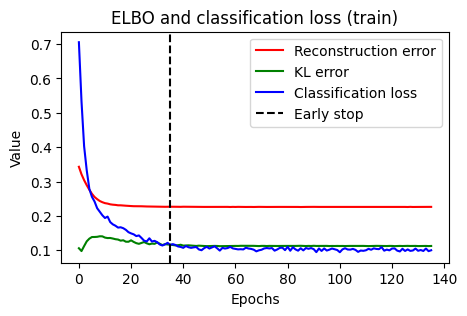

In [266]:
plt.figure(figsize=(5,3), dpi=100)
plt.plot(train_loss[0], 'r', label='Reconstruction error')
plt.plot(train_loss[1], 'g', label='KL error')
plt.plot(train_loss[2], 'b', label='Classification loss')
plt.axvline(x=best_epoch, color='black', linestyle = '--', label="Early stop")

plt.title('ELBO and classification loss (train)')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()

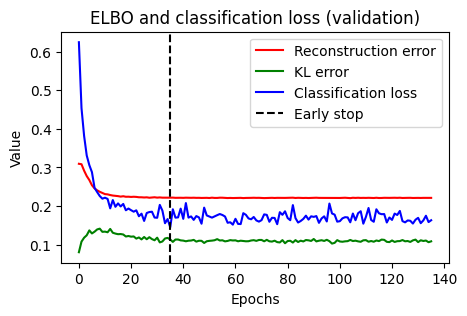

In [267]:
plt.figure(figsize=(5,3), dpi=100)
plt.plot(val_loss[0], 'r', label='Reconstruction error')
plt.plot(val_loss[1], 'g', label='KL error')
plt.plot(val_loss[2], 'b', label='Classification loss')
plt.axvline(x=best_epoch, color='black', linestyle = '--', label="Early stop")

plt.title('ELBO and classification loss (validation)')
plt.xlabel('Epochs')
plt.ylabel('Value')
plt.legend()

Al momento de entrenar se nota que hay un leve sobreajuste en el modelo, los errores de entrenamiento son ligeramente inferiores que en validación, no se aprecia un crecimiento en el error de validación sostenido

Text(0.5, 1.0, 'Classification loss')

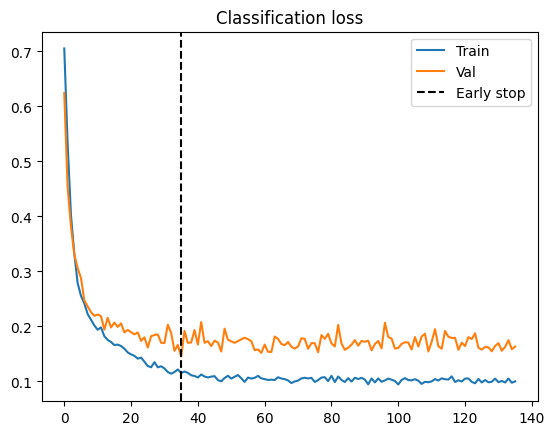

In [245]:
plt.plot(train_loss[2], label="Train")
plt.plot(val_loss[2], label="Val")
plt.axvline(x=best_epoch, color='black', linestyle = '--', label="Early stop")

plt.legend()
plt.title("Classification loss")

Notar que los los mejores pesos para la tarea de clasificación según validación son de la epoca:

In [246]:
print(f"Best validation epoch for classification: {np.argmin(val_loss[2])+1}")
print(f"Actual early stop epoch: {best_epoch+1}")

Best validation epoch for classification: 36
Actual early stop epoch: 36


In [247]:
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in test_loader:
        pred_x, mu, logvar, cls_values = vae(images)
        probs = torch.softmax(cls_values, dim=1)    
        predicted = torch.argmax(probs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("\nReporte de clasificación (VAE):")
print(classification_report(
    y_true,
    y_pred,
    digits=4
))


Reporte de clasificación (VAE):
              precision    recall  f1-score   support

           0     0.9430    0.9398    0.9414       299
           1     0.9412    0.9443    0.9427       305

    accuracy                         0.9421       604
   macro avg     0.9421    0.9420    0.9420       604
weighted avg     0.9421    0.9421    0.9421       604



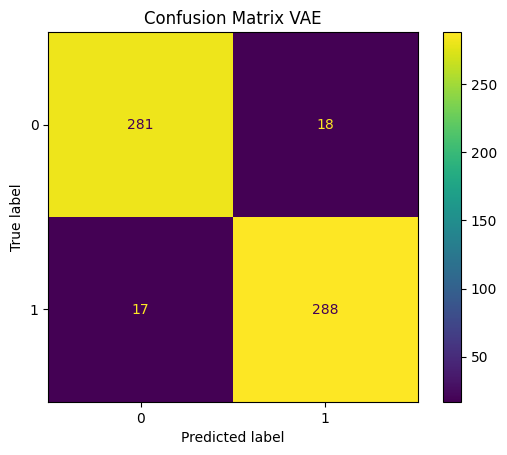

[[281  18]
 [ 17 288]]


In [248]:
cm = confusion_matrix(y_true, y_pred)
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm)
cm_plot.plot()
plt.title("Confusion Matrix VAE")
plt.show()

print(cm)

In [249]:
def error_and_uncertainty(test_loader, T=512, tau=1):
    N = len(test_loader.dataset)

    all_p = torch.zeros(T, N, 2, device=device)
    all_logits = torch.zeros(T, N, 2, device=device)
    for i in range(T):
        with torch.no_grad():
            idx = 0
            for images, labels in test_loader:
                batch_size = len(labels)
                images = images.to(device)

                _, _, _, cls_values = vae(images)
                all_logits[i, idx:idx+batch_size] = cls_values
                all_p[i, idx:idx+batch_size] = torch.softmax(cls_values / tau, dim=1)
                idx += batch_size

    mean_logits = all_logits.mean(dim=0)
    mean_p = all_p.mean(dim=0)
    y_pred = mean_p.argmax(dim=1)

    epsilon = 1e-8
    first_term = -(mean_p * torch.log(mean_p + epsilon)).sum(dim=1)
    second_term = (all_p * torch.log(all_p + epsilon)).sum(dim=2).mean(dim=0)

    mean_logits = mean_logits.cpu()
    mean_p = mean_p.cpu()
    u = (first_term + second_term).cpu()
    e = (y_pred != test_loader.dataset.y).int().cpu()

    return u, e, mean_logits, mean_p

In [250]:
u, e, mean_logits, mean_p = error_and_uncertainty(test_loader=test_loader)

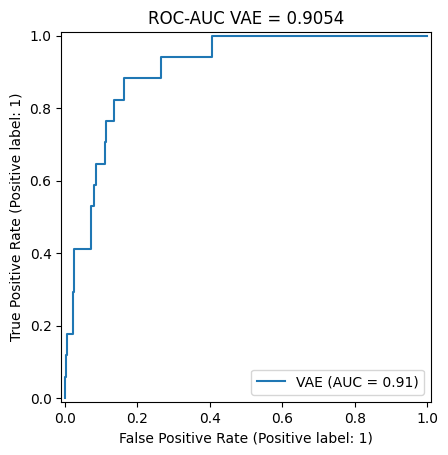

In [251]:
auc = roc_auc_score(e, u)

fig, ax = plt.subplots()
RocCurveDisplay.from_predictions(e, u, name="VAE", ax=ax)
plt.title(f"ROC-AUC VAE = {auc:.4f}")
plt.show()

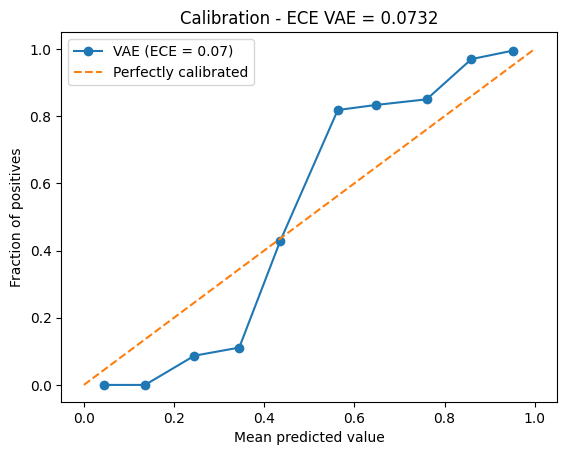

In [275]:
confidence = mean_p[:,1].cpu()
prob_true, prob_pred = calibration_curve(y_true, confidence, n_bins=10)

ece_metric = BinaryCalibrationError(n_bins=10)
ece = ece_metric(confidence.cpu(), y_test.cpu())

plt.plot(prob_pred, prob_true, marker='o', label=f"VAE (ECE = {ece:.2f})")

plt.plot([0,1],[0,1], '--', label="Perfectly calibrated")
plt.title(f"Calibration - ECE VAE = {ece:.4f}")
plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.legend()



El modelo se encuentra descalibrado y su curva tiene forma de zig-zag

### Posibles misslabels

Como la AUC es cercana a 1, nos importa los casos en que desconfiadamente esta correcto o confiadamente se equivoca

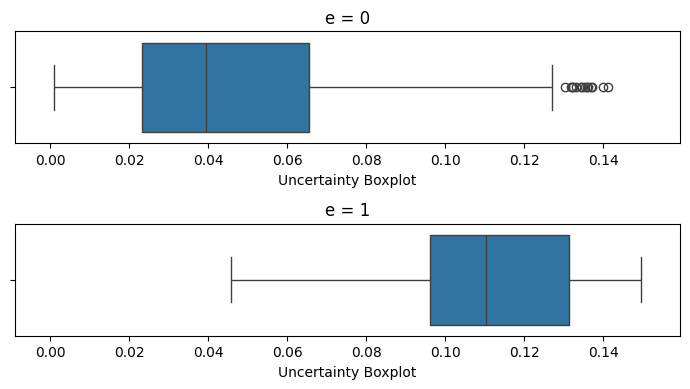

In [273]:
fig, axes = plt.subplots(2, 1, figsize=(7, 4))

min_u = min(u)
max_u = max(u)
for error in range(2):
    vals = u[e==error]
    sns.boxplot(x=vals, ax=axes[error])
    axes[error].set_title(f'e = {error}')
    axes[error].set_xlabel('Uncertainty Boxplot')
    axes[error].set_xlim(min_u-0.01,max_u+0.01)

plt.tight_layout()
plt.show()


## Calibración del modelo

### La literatura

https://arxiv.org/pdf/2308.01222

...but Guo et al. (Guo et al., 2017) empirically demonstrated model tends to be less calibrated without using L2 regularization...

4 Calibration Methods
4.1 Post-hoc Methods

Temperature scaling (TS) is a single-parameter extension of Platt scaling (Platt et al., 1999) and
the most recent addition to the offering of post-hoc methods. It uses a temperature parameter τ to
calibrate the softmax probability:

pi = exp(gi/τ ) sum k j=1 exp(gj /τ ) , i ∈ [1 . . . k]. (11)

where gi is the logit and τ > 0 for all classes is used as a scaling factor to soften model predicted probability, it controls the model’s confidence by adjusting the sharpness of distribution so that the model prediction is not too certain (overconfident) or too uncertain (underconfident). The optimal temperature value is obtained by minimizing negative log likelihood loss (NLL) on the validation dataset.:

τ∗ = arg min τ − ( sum N i=1 log(SOFTMAX(gi, τ )))  (12)

TS simplifies matrix (vector) scaling (Guo et al., 2017) where class-wise τ is considered as a single
parameter, and offers good calibration while maintaining minimum computational complexity (Guo
et al., 2017; Minderer et al., 2021a).

Mozafari et al. (2018) suggested that TS has difficulties in finding optimal τ when the validation
set has a limited number of samples. They proposed attended temperature scaling (ATS) to alleviate
this issue by increasing the number of samples in validation set. The key idea is to gather samples
from each class distribution. Let’s assume p(y|x) is the predicted probability. ATS first divides the
validation set into K subsets with p(y = k|x), k ∈ [1, K], which allows to add more y̸ = k samples
using the Bayesian Theorem (Jin, Lazarow, & Tu, 2017) as the selection criterion:

p(x, y = k) = p(y = k|x) / p(y != k|x) * p(x, y != k) (14)

It indicates that ATS selects the samples with y != k which are more probable to belong to p(x, y = k). 

Bin-wise TS (BTS) (Ji et al., 2019) was proposed to extend TS to multiple equal size bins by using the confidence interval-based binning method. Together with data augmentation, BTS showed
superior performance as compared to TS. Local TS (LTS) (Ding et al., 2021) extends TS to multi-label semantic segmentation and makes it adaptive to local image changes. A local scaling factor is learned for each pixel or voxel.

Q(x, τi(x)) = max l∈L SOFTMAX( gi(x) / τi(x) )(l) (15)

where l is the class index, gi(x) is the logit of input at location x, and The τi(x) is the location-
dependent temperature.

Para esta entrega se utilizará Attended temperature scaling

### Implementación de Attended temperature scaling

In [254]:
def ats_calibration(val_probs, val_logits, y_val, epochs, prior_y0=0.5): 
    # prior suponiendo que las clases balanceadas en la realidad

    tau = nn.Parameter(torch.ones(1, requires_grad=True, device=device))
    prior_y1 = 1 - prior_y0

    curr_loss = float('inf')
    best_tau_val = tau.item()
    best_epoch = 0

    sub0_idx = []
    sub1_idx = []
    for i in range(len(val_probs)):
        p_y1_x = val_probs[i][1].item()
        p_y0_x = val_probs[i][0].item()

        if p_y0_x < 1e-8:
            p_y0_x = 1e-8
        if p_y1_x < 1e-8:
            p_y1_x = 1e-8

        if y_val[i] == 0: 
            sub0_idx.append(i)
            filter_prob = p_y1_x / p_y0_x * prior_y0
            if np.random.rand() < filter_prob:
                sub1_idx.append(i)
        else:
            sub1_idx.append(i)
            filter_prob = p_y0_x / p_y1_x * prior_y1
            if np.random.rand() < filter_prob:
                sub0_idx.append(i)
    
    sub0_logits = val_logits[sub0_idx].to(device)
    sub0_labels = y_val[sub0_idx].long().to(device)

    sub1_logits = val_logits[sub1_idx].to(device)
    sub1_labels = y_val[sub1_idx].long().to(device)

    optimizer = torch.optim.Adam(params=[tau], lr=1e-2)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
                                                        mode='min',
                                                        patience=5,
                                                        factor=0.5,
                                                        min_lr=1e-3)    
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        cal_sub0_logits = sub0_logits / tau
        cal_sub1_logits = sub1_logits / tau
        loss_0 = loss_fn(cal_sub0_logits, sub0_labels)
        loss_1 = loss_fn(cal_sub1_logits, sub1_labels)
        loss = 0.5 * loss_0 + 0.5 * loss_1

        if(loss < curr_loss):
            curr_loss = loss.item()
            best_tau_val = tau.item()
            best_epoch = epoch

        loss.backward()
        optimizer.step()
        scheduler.step(loss.detach())
        
        print(f"Epoch {epoch+1}/{epochs}, Loss: {loss.item():.4f}, tau: {tau.item():.4f}")

    print(f"Using tau ({best_tau_val:.4f}) from epoch {best_epoch + 1}")

    return best_tau_val

### Busqueda de tau

In [255]:
u_val, e_val, mean_logits_val, mean_p_val = error_and_uncertainty(test_loader=val_loader)
tau = ats_calibration(mean_p_val, mean_logits_val, y_val, epochs=1000)

Epoch 1/1000, Loss: 0.1538, tau: 0.9900
Epoch 2/1000, Loss: 0.1529, tau: 0.9800
Epoch 3/1000, Loss: 0.1521, tau: 0.9700
Epoch 4/1000, Loss: 0.1514, tau: 0.9600
Epoch 5/1000, Loss: 0.1506, tau: 0.9501
Epoch 6/1000, Loss: 0.1499, tau: 0.9402
Epoch 7/1000, Loss: 0.1491, tau: 0.9302
Epoch 8/1000, Loss: 0.1484, tau: 0.9204
Epoch 9/1000, Loss: 0.1477, tau: 0.9105
Epoch 10/1000, Loss: 0.1471, tau: 0.9007
Epoch 11/1000, Loss: 0.1464, tau: 0.8910
Epoch 12/1000, Loss: 0.1458, tau: 0.8813
Epoch 13/1000, Loss: 0.1452, tau: 0.8717
Epoch 14/1000, Loss: 0.1446, tau: 0.8621
Epoch 15/1000, Loss: 0.1441, tau: 0.8527
Epoch 16/1000, Loss: 0.1435, tau: 0.8433
Epoch 17/1000, Loss: 0.1430, tau: 0.8340
Epoch 18/1000, Loss: 0.1425, tau: 0.8249
Epoch 19/1000, Loss: 0.1421, tau: 0.8158
Epoch 20/1000, Loss: 0.1417, tau: 0.8069
Epoch 21/1000, Loss: 0.1413, tau: 0.7981
Epoch 22/1000, Loss: 0.1409, tau: 0.7895
Epoch 23/1000, Loss: 0.1406, tau: 0.7811
Epoch 24/1000, Loss: 0.1403, tau: 0.7728
Epoch 25/1000, Loss: 0.14

### Resultados optimizados

In [256]:
y_true, y_pred_cal = [], []

with torch.no_grad():
    for images, labels in test_loader:
        pred_x, mu, logvar, cls_values = vae(images)
        probs = torch.softmax(cls_values/tau, dim=1)    
        predicted = torch.argmax(probs, dim=1)

        y_true.extend(labels.cpu().numpy())
        y_pred_cal.extend(predicted.cpu().numpy())

print("\nReporte de clasificación (VAE calibrated):")
print(classification_report(
    y_true,
    y_pred_cal,
    digits=4
))


Reporte de clasificación (VAE calibrated):
              precision    recall  f1-score   support

           0     0.9562    0.9498    0.9530       299
           1     0.9511    0.9574    0.9542       305

    accuracy                         0.9536       604
   macro avg     0.9537    0.9536    0.9536       604
weighted avg     0.9537    0.9536    0.9536       604



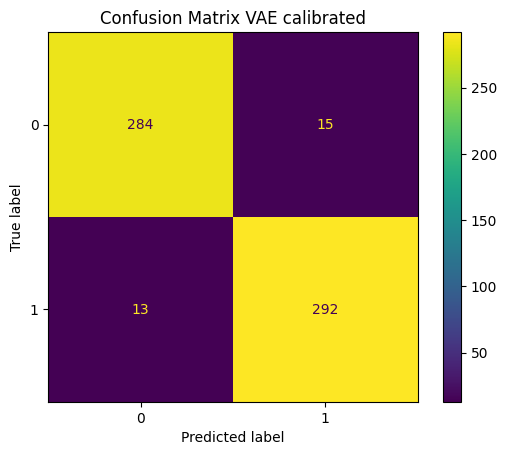

[[284  15]
 [ 13 292]]


In [257]:
cm = confusion_matrix(y_true, y_pred_cal)
cm_plot = ConfusionMatrixDisplay(confusion_matrix=cm)
cm_plot.plot()
plt.title("Confusion Matrix VAE calibrated")
plt.show()

print(cm)

In [258]:
u_cal, e_cal, mean_logits_cal, mean_p_cal = error_and_uncertainty(test_loader=test_loader, tau=tau)

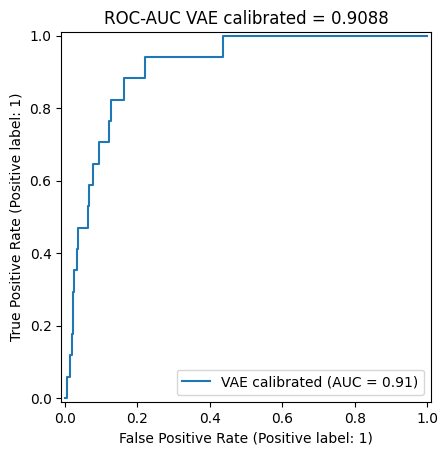

In [259]:
auc_cal = roc_auc_score(e_cal, u_cal)
fig, ax = plt.subplots()
roc_cal = RocCurveDisplay.from_predictions(e_cal, u_cal, name="VAE calibrated", ax=ax)
plt.title(f"ROC-AUC VAE calibrated = {auc_cal:.4f}")
plt.show()

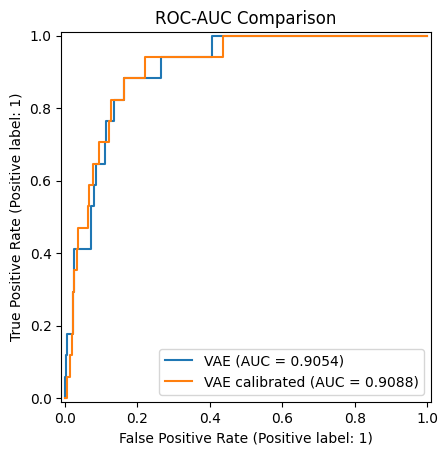

In [263]:
fig, ax = plt.subplots()

roc = RocCurveDisplay.from_predictions(e, u, ax=ax)
roc_cal = RocCurveDisplay.from_predictions(e_cal, u_cal, ax=ax)

line_uncal = roc.line_
line_cal = roc_cal.line_

ax.legend(
    handles=[line_uncal, line_cal],
    labels=[
        f"VAE (AUC = {auc:.4f})",
        f"VAE calibrated (AUC = {auc_cal:.4f})",
    ]
)
ax.set_title("ROC-AUC Comparison")
plt.show()

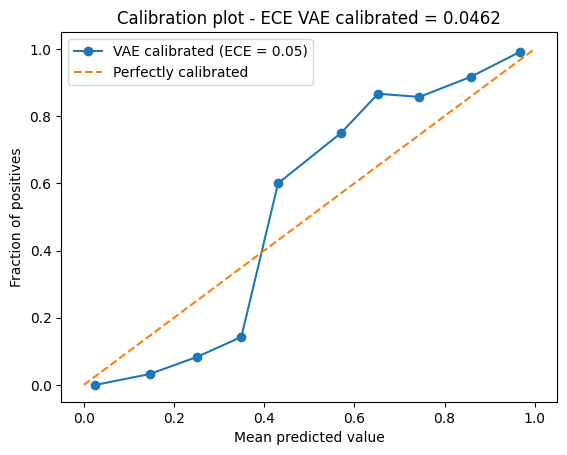

In [261]:
confidence_cal = mean_p_cal[:,1].cpu()
prob_true_cal, prob_pred_cal = calibration_curve(y_test.cpu(), confidence_cal, n_bins=10)

ece_cal = ece_metric(confidence_cal.cpu(), y_test.cpu())

plt.plot(prob_pred_cal, prob_true_cal, marker='o', label=f"VAE calibrated (ECE = {ece_cal:.2f})")

plt.plot([0,1],[0,1], '--', label="Perfectly calibrated")
plt.title(f"Calibration plot - ECE VAE calibrated = {ece_cal:.4f}")
plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.legend()



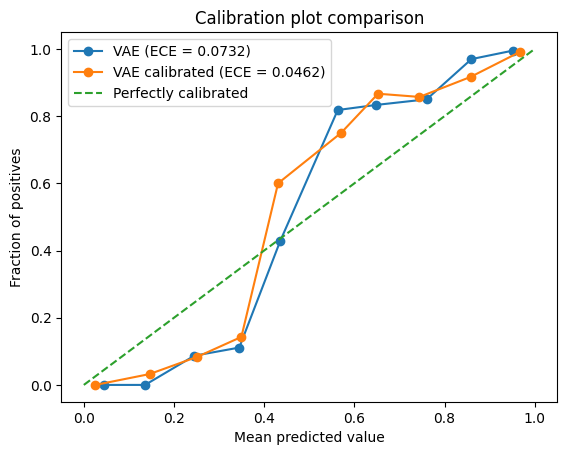

In [262]:
plt.plot(prob_pred, prob_true, marker='o', label=f"VAE (ECE = {ece:.4f})")
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label=f"VAE calibrated (ECE = {ece_cal:.4f})")

plt.plot([0,1],[0,1], '--', label="Perfectly calibrated")
plt.title("Calibration plot comparison")
plt.xlabel("Mean predicted value")
plt.ylabel("Fraction of positives")
plt.legend()
